In [1]:
import os
import pandas as pd
import numpy as np
import time
from collections import Counter

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import missingno as ms
import matplotlib.pyplot as plt
import seaborn as sns

import traceback
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(
    style = "whitegrid",
    palette = "colorblind",
    context = "notebook"
)

plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "axes.titlesize" : 12,
    "axes.labelsize" : 8,
    "axes.grid" : True,
    "font.size" : 4,
    "lines.linewidth" : 3
})

In [3]:
np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4f}".format)

In [4]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/features/preprocessing.py"

In [5]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.data import preprocessing

In [6]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/interim")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates=["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
0,2020-01-01 00:00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0
1,2020-01-01 01:00:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0
2,2020-01-01 02:00:00,6.0000,93,0.0000,7.8000,12.7000,1004.6000,1019.4000,0
3,2020-01-01 03:00:00,5.8000,94,0.0000,7.6000,12.3000,1004.6000,1019.5000,0
4,2020-01-01 04:00:00,5.7000,95,0.0000,7.6000,13.1000,1004.7000,1019.6000,0


In [7]:
cleaner = preprocessing.clean_dataset(weather_data)
cleaner.drop_duplicate_record()
cleaner.drop_null_records()
cleaner.remove_noice()
weather_data = cleaner.data

In [8]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               52608 non-null  datetime64[ns]
 1   Temperature                        52608 non-null  float64       
 2   Relative_humidity                  52608 non-null  int64         
 3   Rain                               52608 non-null  float64       
 4   Soil_temperature                   52608 non-null  float64       
 5   Wind_speed                         52608 non-null  float64       
 6   Surface_pressure                   52608 non-null  float64       
 7   Pressure_msl                       52608 non-null  float64       
 8   is_day                             52608 non-null  int64         
 9   Rolling Mean of Temperature        52585 non-null  float64       
 10  Rolling Mean of Relative_humidity 

In [9]:
num_cols = weather_data.select_dtypes(include = ["float64","int64"]).columns

weather_data[num_cols].describe()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Pressure_msl,Rolling Mean of is_day,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day
count,52608.0000,52608.0000,52608.0000,52608.0000,52608.0000,52608.0000,52608.0000,52608.0000,52585.0000,52585.0000,...,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000,52585.0000
mean,24.8606,67.3062,0.1342,25.9746,15.2347,994.1546,1007.9183,0.5058,24.8666,67.2975,...,1007.9143,0.5058,3.6794,12.9018,0.2755,2.9442,4.6385,1.3837,1.4256,0.5074
std,7.4598,22.8985,0.7762,7.1798,7.7181,6.6220,6.9727,0.5000,6.3977,18.6372,...,6.8249,0.0571,1.3233,4.2692,0.6401,1.0817,1.7142,0.2582,0.2713,0.0031
min,4.0000,6.0000,0.0000,6.6000,0.0000,976.2000,988.9000,0.0000,8.7875,14.2083,...,992.2333,0.4167,0.3049,1.1389,0.0000,0.2493,1.1403,0.5069,0.5340,0.5036
25%,19.6000,51.0000,0.0000,20.5000,9.4000,988.6000,1002.0000,0.0000,19.4917,56.2083,...,1002.0750,0.4583,2.4681,9.5139,0.0000,2.0367,3.3830,1.2111,1.2437,0.5036
50%,26.3000,72.0000,0.0000,27.5000,14.6000,994.0000,1007.6000,1.0000,27.0917,72.0000,...,1007.3750,0.5000,3.8555,12.9194,0.0000,2.9462,4.3727,1.3558,1.3950,0.5090
75%,29.9000,87.0000,0.0000,30.8000,20.4000,1000.0000,1014.1000,1.0000,29.4500,82.3750,...,1014.1833,0.5833,4.6963,16.0759,0.1978,3.7122,5.5851,1.5269,1.5727,0.5108
max,46.1000,100.0000,38.5000,46.8000,59.1000,1012.0000,1026.7000,1.0000,39.5667,95.3750,...,1023.7833,0.5833,7.1750,29.3359,10.9375,6.2963,15.3060,3.4134,3.6334,0.5108


## **Exploratory Data Analysis (EDA)**

In [10]:
weather_data.set_index("Date", inplace = True)
weather_data.head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Pressure_msl,Rolling Mean of is_day,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00,6.0000,93,0.0000,7.8000,12.7000,1004.6000,1019.4000,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 03:00:00,5.8000,94,0.0000,7.6000,12.3000,1004.6000,1019.5000,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00,5.7000,95,0.0000,7.6000,13.1000,1004.7000,1019.6000,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
weather_data.index.is_monotonic_increasing

True

In [12]:
weather_data.resample("D").max().sort_values(by="Temperature", ascending=False).head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Pressure_msl,Rolling Mean of is_day,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-31,46.1000,45,0.0000,46.2000,24.5000,987.5000,1000.5000,1,39.4708,33.2917,...,997.9458,0.5833,4.5135,13.2564,0.0000,4.0468,8.9406,1.7107,1.8054,0.5036
2024-06-18,45.7000,47,0.0000,46.2000,46.9000,984.1000,997.1000,1,39.5667,32.0833,...,996.9875,0.5833,4.9274,13.8593,0.0000,4.3245,10.0009,1.9909,2.1439,0.5036
2024-05-29,45.6000,67,0.0000,46.4000,30.8000,982.8000,996.0000,1,37.3375,42.4583,...,994.0292,0.5833,5.6571,17.6487,0.0000,4.7974,8.9828,2.0167,2.1378,0.5036
2024-06-16,45.5000,40,0.0000,46.8000,30.0000,985.9000,998.9000,1,38.7125,28.1250,...,997.0292,0.5833,4.8705,7.2632,0.0000,4.4496,8.3891,1.5662,1.6639,0.5036
2024-06-17,45.4000,64,0.0000,46.8000,33.0000,985.9000,999.1000,1,38.7583,31.1250,...,997.1583,0.5833,5.0767,14.4320,0.0000,4.4085,9.3389,1.3714,1.5042,0.5036


In [13]:
weather_data.resample("M").max().sort_values(by="Temperature", ascending=False).head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Pressure_msl,Rolling Mean of is_day,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-31,46.1000,77,5.8000,46.4000,39.6000,997.4000,1011.1000,1,39.4708,59.8333,...,1007.8208,0.5833,6.2820,20.7207,1.1839,5.2896,12.6605,2.6030,2.7501,0.5036
2024-06-30,45.7000,96,17.7000,46.8000,46.9000,992.9000,1006.5000,1,39.5667,84.0417,...,1002.7750,0.5833,5.7488,22.4593,3.8060,5.1628,11.5103,2.4276,2.6166,0.5036
2022-05-31,44.0000,97,11.6000,44.2000,43.6000,994.8000,1008.3000,1,35.1667,77.6667,...,1005.5792,0.5833,5.6809,25.9526,2.3852,5.0654,12.4145,2.4714,2.5159,0.5036
2022-04-30,43.8000,92,0.2000,44.2000,56.0000,998.3000,1011.6000,1,34.8500,49.8750,...,1008.9542,0.5833,7.1750,29.3359,0.0408,6.2963,12.5363,2.3446,2.4119,0.5108
2023-05-31,43.8000,98,12.1000,43.8000,44.5000,998.1000,1011.8000,1,34.3167,82.2917,...,1009.4667,0.5833,6.6712,22.0196,2.6203,5.4144,10.4807,2.4611,2.5784,0.5036


In [14]:
weather_data.resample("Y").max().sort_values(by="Temperature", ascending=False)

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling Mean of Pressure_msl,Rolling Mean of is_day,Rolling std of Temperature,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-31,46.1000,100,38.5000,46.8000,57.3000,1009.8000,1024.3000,1,39.5667,93.8333,...,1021.0750,0.5833,6.5316,22.8425,10.9375,5.3740,13.1816,2.6030,2.7501,0.5108
2022-12-31,44.0000,100,20.2000,45.8000,58.7000,1009.5000,1024.0000,1,38.2375,94.5417,...,1022.0958,0.5833,7.1750,29.3359,4.3484,6.2963,13.8419,3.4134,3.6334,0.5108
2023-12-31,43.8000,100,16.9000,44.5000,51.1000,1012.0000,1026.7000,1,38.1500,92.3750,...,1023.7833,0.5833,6.6712,25.9322,4.2273,5.4144,11.5630,2.7670,2.9083,0.5108
2020-12-31,42.5000,100,16.0000,42.1000,59.1000,1009.5000,1023.8000,1,35.3083,95.3750,...,1020.9167,0.5833,6.2814,25.2671,4.5309,5.3180,15.3060,2.5466,2.6530,0.5108
2025-12-31,41.9000,100,11.8000,41.6000,49.7000,1008.7000,1023.2000,1,36.1208,93.7917,...,1020.1042,0.5833,6.8750,24.4054,2.5146,5.7712,10.1903,2.7595,2.7400,0.5108
2021-12-31,41.5000,100,18.3000,42.6000,56.0000,1010.0000,1024.4000,1,34.1958,93.5833,...,1022.3042,0.5833,7.0850,24.4758,5.1007,6.1662,13.2046,3.2039,3.1823,0.5108


In [15]:
def plot_feature(column_name):
    data = weather_data[column_name].resample("M").sum()
    data.plot(figsize = (9,4), title = f"{column_name} Monthly plot")
    plt.show()

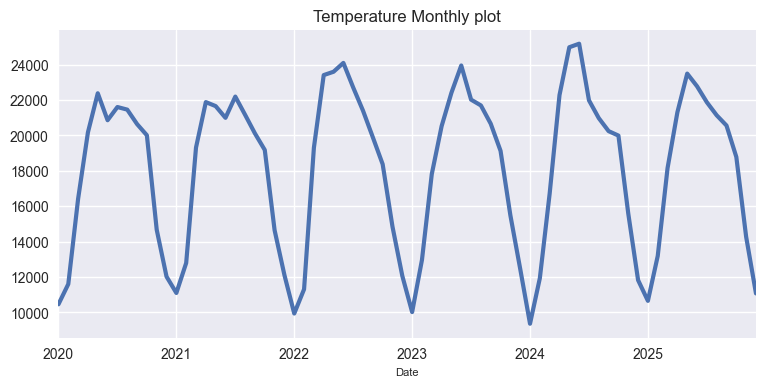

In [16]:
plot_feature("Temperature")

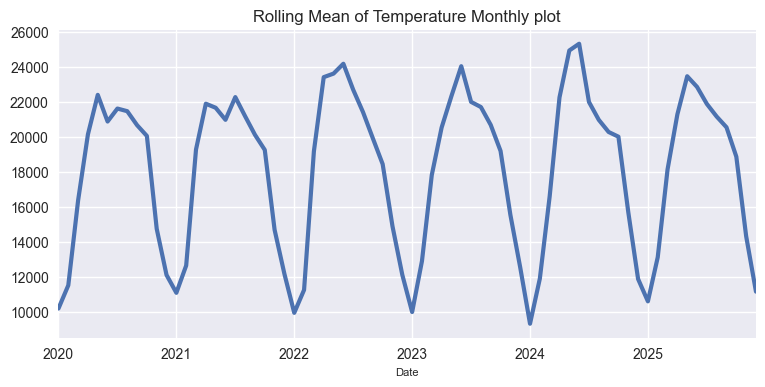

In [17]:
plot_feature("Rolling Mean of Temperature")

In [18]:
def decomposision(feature):
    
    docompose_additive_model = seasonal_decompose(feature , model = "additive" , period = 8760)
    trend_additive = docompose_additive_model.trend
    seasonality_additive = docompose_additive_model.seasonal
    residual_additive = docompose_additive_model.resid

    plt.figure(figsize = (12,9))
    plt.subplot(411)
    plt.plot(feature , label = "original")
    plt.legend()
    plt.subplot(412)
    plt.plot(trend_additive , label = "trend")
    plt.legend()
    plt.subplot(413)
    plt.plot(seasonality_additive , label = "seasonality")
    plt.legend()
    plt.subplot(414)
    plt.plot(residual_additive , label = "residual")
    plt.legend()
    plt.show()
    

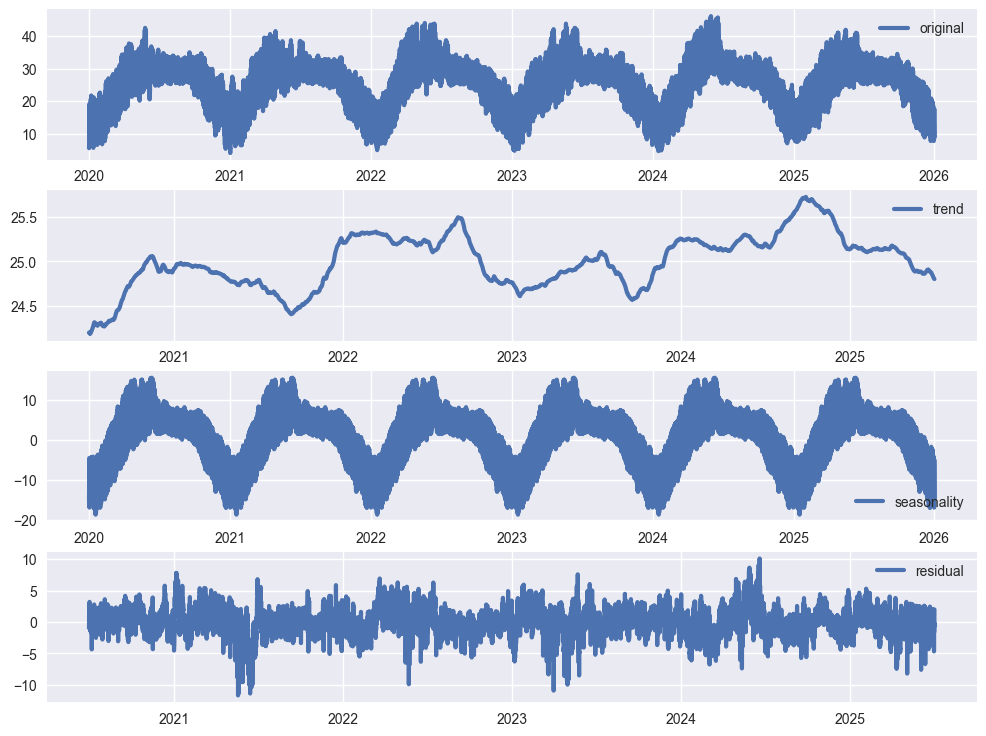

In [19]:
decomposision(weather_data["Temperature"])

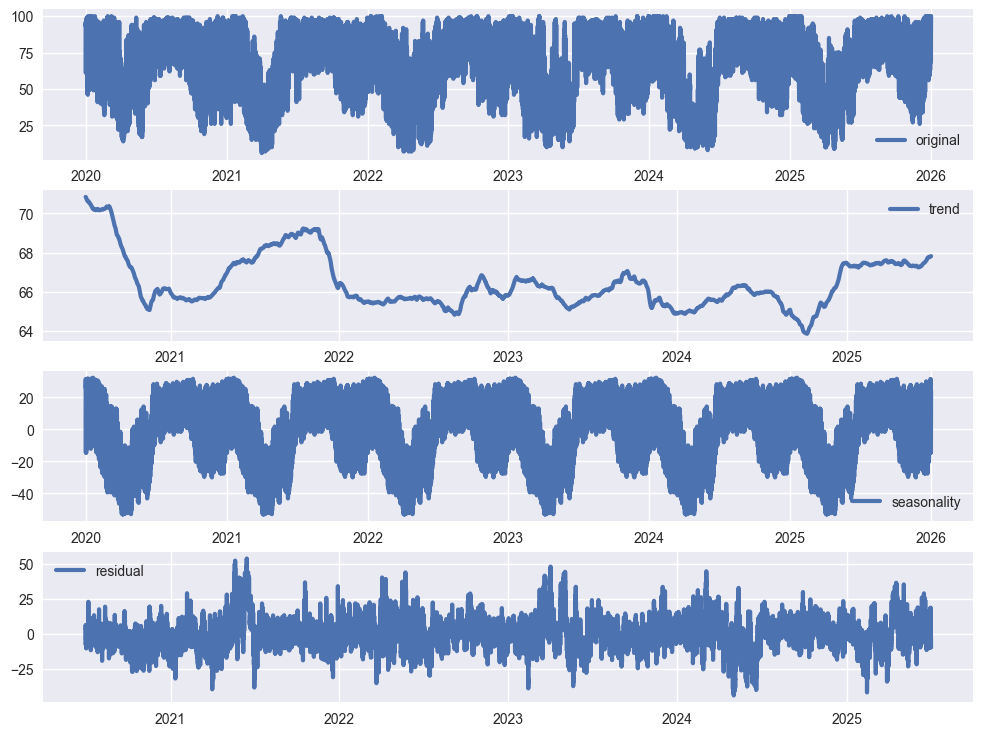

In [20]:
decomposision(weather_data["Relative_humidity"])

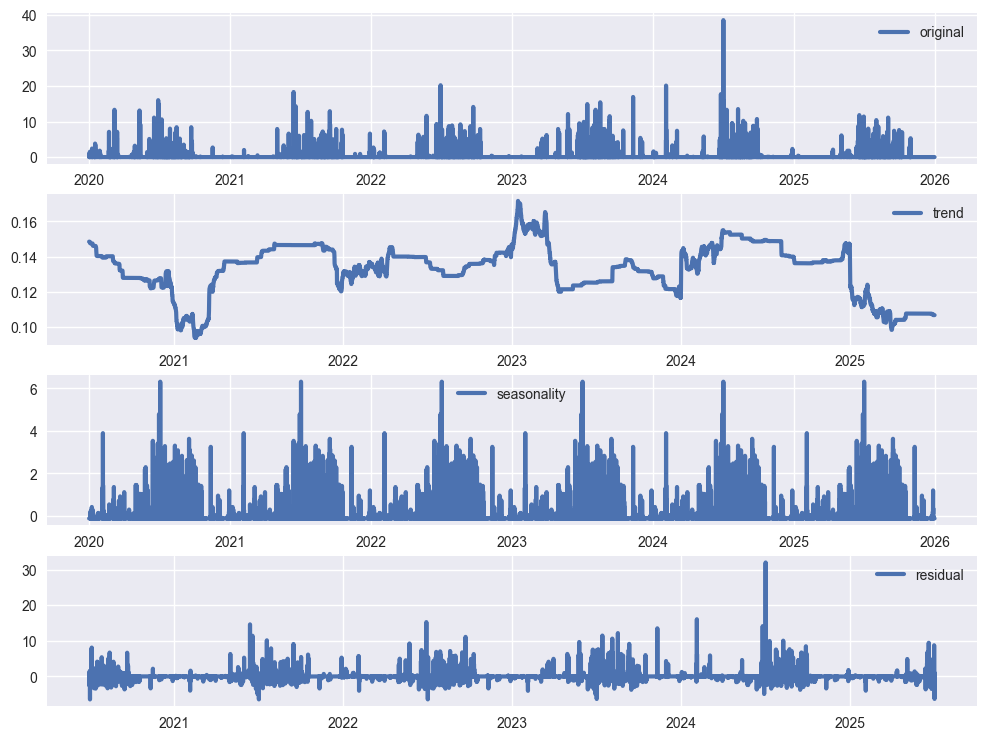

In [21]:
decomposision(weather_data["Rain"])

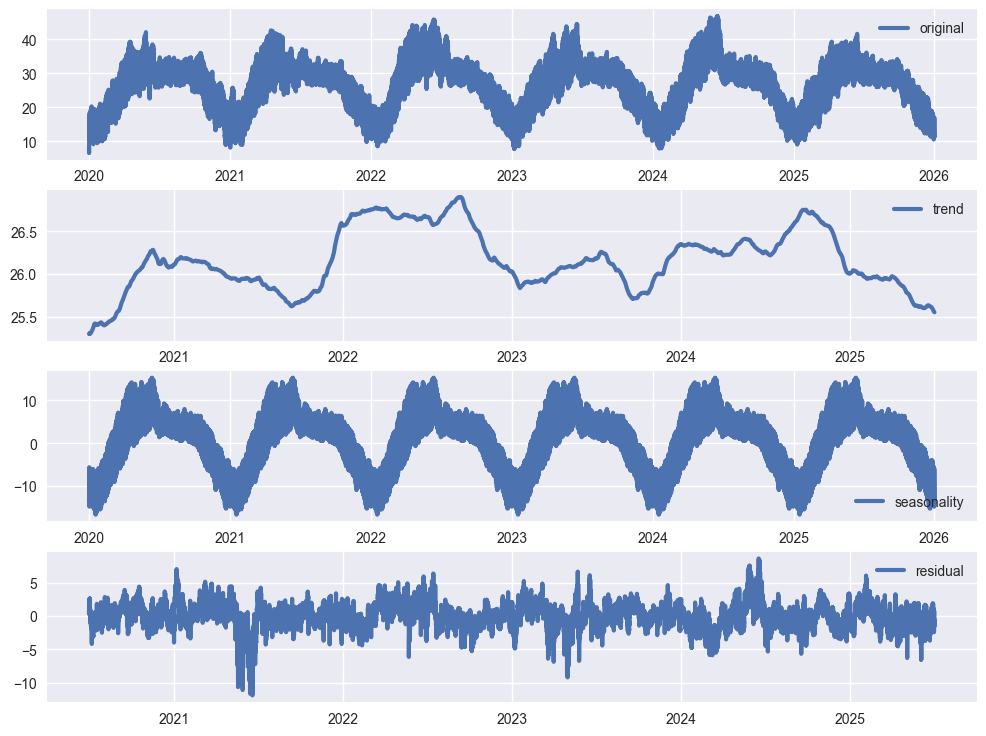

In [22]:
decomposision(weather_data["Soil_temperature"])

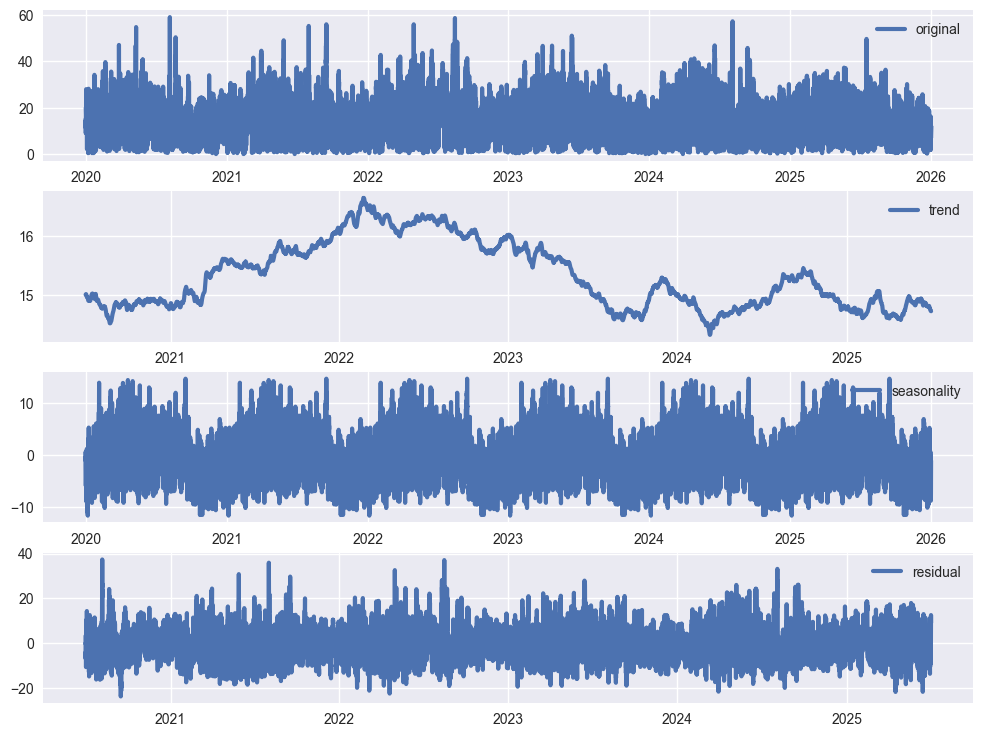

In [23]:
decomposision(weather_data["Wind_speed"])

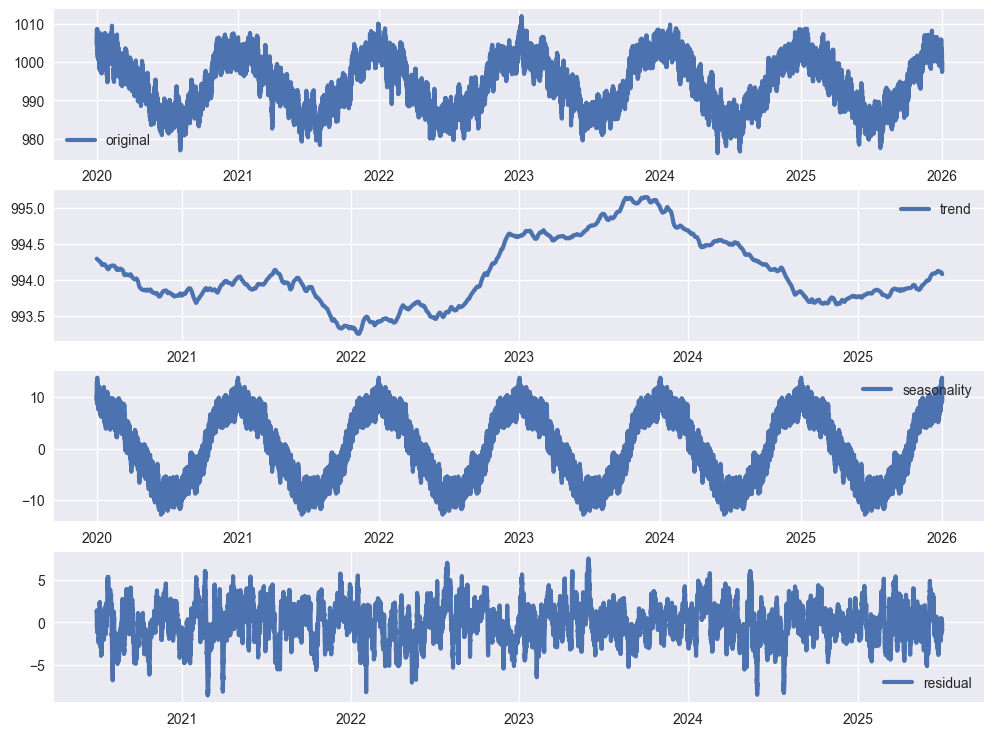

In [24]:
decomposision(weather_data["Surface_pressure"])

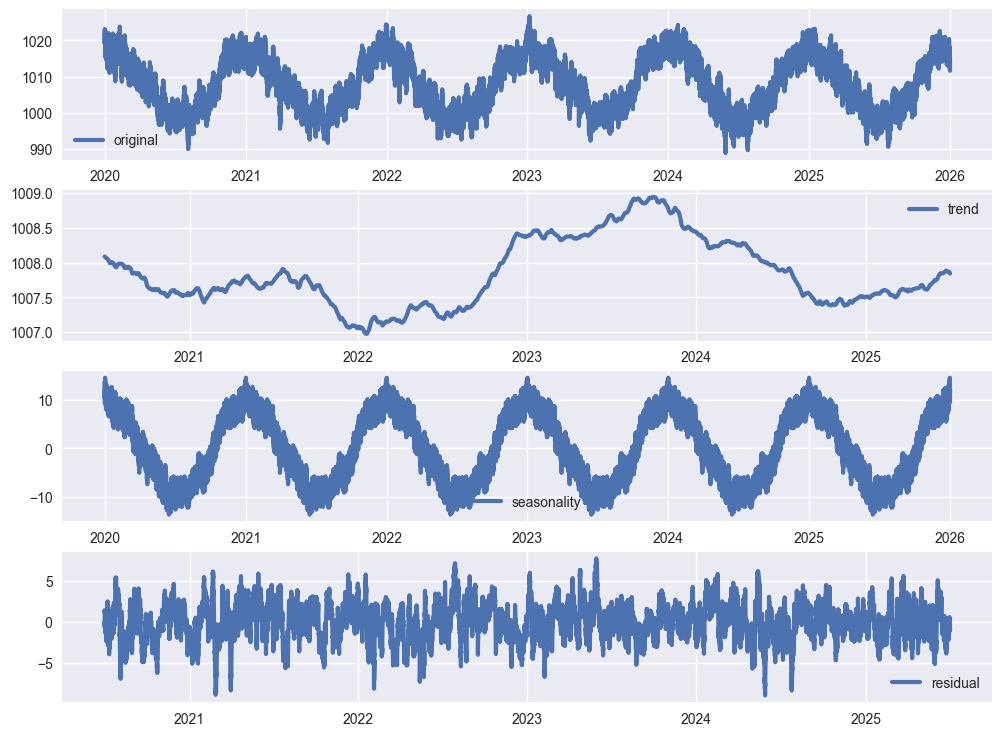

In [25]:
decomposision(weather_data["Pressure_msl"])

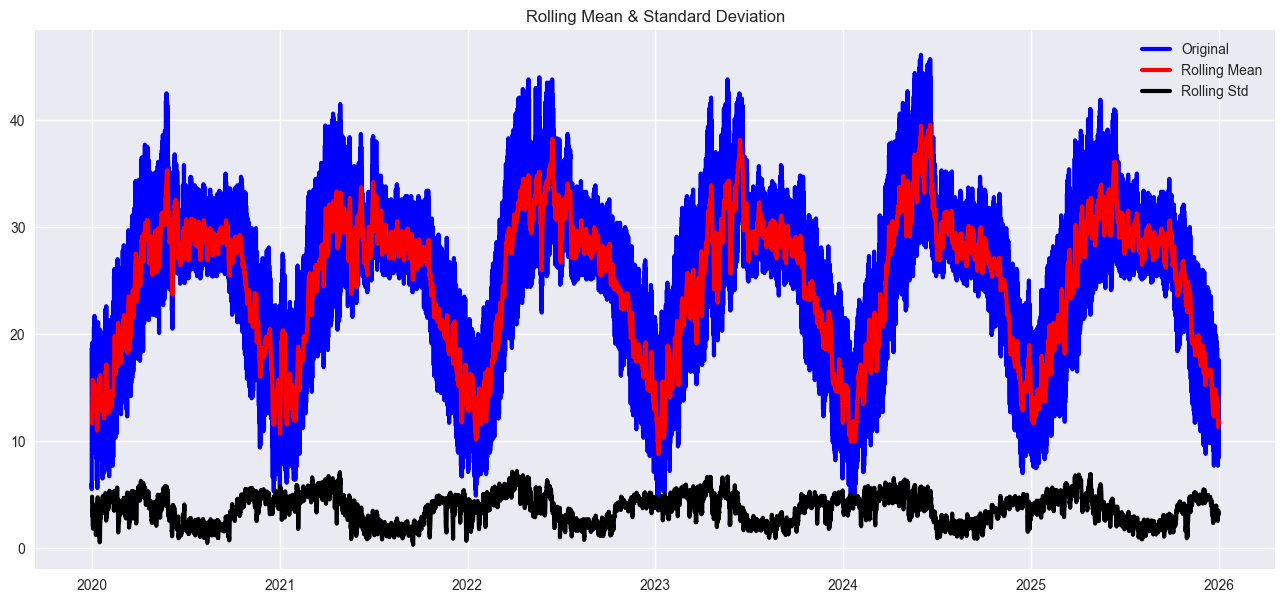

In [26]:
plt.figure(figsize=(16,7))
fig = plt.figure(1)

# Plot rolling statistics:
orig = plt.plot(weather_data["Temperature"], color='blue', label='Original')
mean = plt.plot(weather_data["Rolling Mean of Temperature"], color='red', label='Rolling Mean')
std = plt.plot(weather_data["Rolling std of Temperature"], color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

In [27]:
def stationarity_check(column_name):

    result = adfuller(column_name.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Number of Lags Used:", result[2])
    print("Number of Observations Used:", result[3])

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("The time series is Stationary (Reject the Null Hypothesis).")
    else:
        print("The time series is Non-Stationary (Fail to Reject the Null Hypothesis).")

In [28]:
stationarity_check(weather_data["Temperature"])

ADF Statistic: -4.196301572387284
p-value: 0.0006684631132067368
Number of Lags Used: 58
Number of Observations Used: 52549

Critical Values:
1%: -3.430474448028772
5%: -2.861595003531693
10%: -2.5667992765505505
The time series is Stationary (Reject the Null Hypothesis).


In [29]:
stationarity_check(weather_data["Relative_humidity"])

ADF Statistic: -7.584239755986333
p-value: 2.6324273434823936e-11
Number of Lags Used: 57
Number of Observations Used: 52550

Critical Values:
1%: -3.430474445660473
5%: -2.8615950024849743
10%: -2.566799275993413
The time series is Stationary (Reject the Null Hypothesis).


In [30]:
stationarity_check(weather_data["Rain"])

ADF Statistic: -22.035721888976617
p-value: 0.0
Number of Lags Used: 55
Number of Observations Used: 52552

Critical Values:
1%: -3.430474440924146
5%: -2.8615950003916564
10%: -2.566799274879202
The time series is Stationary (Reject the Null Hypothesis).


In [31]:
stationarity_check(weather_data["Soil_temperature"])

ADF Statistic: -3.5869995757772686
p-value: 0.006014487507233817
Number of Lags Used: 52
Number of Observations Used: 52555

Critical Values:
1%: -3.4304744338203306
5%: -2.8615949972519785
10%: -2.5667992732080442
The time series is Stationary (Reject the Null Hypothesis).


In [32]:
stationarity_check(weather_data["Wind_speed"])

ADF Statistic: -22.58615648866158
p-value: 0.0
Number of Lags Used: 52
Number of Observations Used: 52555

Critical Values:
1%: -3.4304744338203306
5%: -2.8615949972519785
10%: -2.5667992732080442
The time series is Stationary (Reject the Null Hypothesis).


In [33]:
stationarity_check(weather_data["Surface_pressure"])

ADF Statistic: -4.892336527827408
p-value: 3.609220417427178e-05
Number of Lags Used: 58
Number of Observations Used: 52549

Critical Values:
1%: -3.430474448028772
5%: -2.861595003531693
10%: -2.5667992765505505
The time series is Stationary (Reject the Null Hypothesis).


In [34]:
stationarity_check(weather_data["Pressure_msl"])

ADF Statistic: -4.778795024059559
p-value: 5.9700009313940686e-05
Number of Lags Used: 58
Number of Observations Used: 52549

Critical Values:
1%: -3.430474448028772
5%: -2.861595003531693
10%: -2.5667992765505505
The time series is Stationary (Reject the Null Hypothesis).


In [35]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52608 entries, 2020-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52608 non-null  float64
 1   Relative_humidity                  52608 non-null  int64  
 2   Rain                               52608 non-null  float64
 3   Soil_temperature                   52608 non-null  float64
 4   Wind_speed                         52608 non-null  float64
 5   Surface_pressure                   52608 non-null  float64
 6   Pressure_msl                       52608 non-null  float64
 7   is_day                             52608 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [36]:
type(weather_data)

pandas.core.frame.DataFrame

In [37]:
try:
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
    null_cols = [col for col in weather_data.columns if "Rolling" in col]
    weather_data = weather_data.dropna(subset=null_cols)
    weather_data = weather_data.drop(columns = ["Rolling Mean of is_day","Rolling std of is_day"])
    weather_data.to_csv("clean_weather_data.csv", index = False)
    print("file saved Successfully!")
except Exception as e:
    print("faild!")
    traceback.print_exc()

file saved Successfully!


In [38]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi